In [58]:
import sys
sys.path.append('~/where/you/download/the/script/')
import scattering
import numpy as np
import matplotlib.pyplot as plt
import xsar
import cv2
import glob
import scipy
import xarray as xr
from tqdm import tqdm
import dask
import random
import torch
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# Load data from https://www.openml.org/d/554
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X.reshape((-1, 28, 28)).astype("float32")

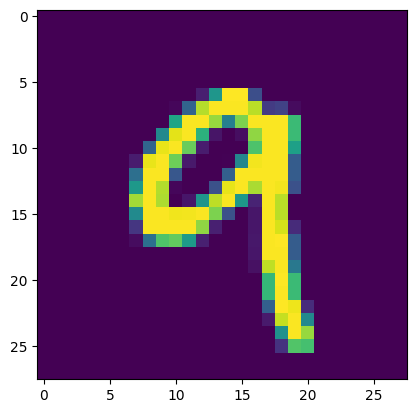

In [39]:
plt.imshow(X[110,:, :])

In [72]:
N_data_points = 1000
pixels = X.shape[-1]
M = N = pixels; J = int(np.log2(pixels)//1); L = 8
st_calc = scattering.Scattering2d(M, N, J, L, device='mps') 

# calculate scattering statistics (mean and correlation)
# s_mean = st_calc.scattering_coef(imagettes_stacked)
s_covs = []
s_means = []
indices = []
for i in tqdm(range(N_data_points)):
    # s_mean = st_calc.scattering_coef(imagettes_stacked)
    # s_mean = st_calc.scattering_coef(np.expand_dims(X[i,:,:], axis = 0))
    # s_means.append(s_mean)
    s_cov  = st_calc.scattering_cov(np.expand_dims(X[i,:,:], axis = 0))
    s_covs.append(s_cov)

100%|██████████| 1000/1000 [00:20<00:00, 49.10it/s]


In [81]:
x = np.squeeze(np.array([i['for_synthesis'] for i in s_covs]))
# x = np.squeeze(np.array([i['for_synthesis'] for i in s_means]))

# mask = np.all(np.isnan(x) | np.equal(x, 0), axis=1)
# x_masked = x[~mask]

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=0.80)
x_scaled_pca = pca.fit_transform(x_scaled)
x_scaled_pca.shape

(1000, 55)

In [49]:
knn = NearestNeighbors(n_neighbors=7)
knn.fit(x_scaled_pca)
distance_mat, neighbours_mat = knn.kneighbors(x_scaled_pca)

In [82]:
kmeans = KMeans(n_clusters=10, random_state=42)
predictions = kmeans.fit_predict(x_scaled_pca)

In [87]:
from sklearn.manifold import TSNE

# Create a t-SNE model with 2 components (for 2D visualization)
tsne = TSNE(n_components=2, random_state=42, perplexity=50)

# Fit and transform the data
x_tsne = tsne.fit_transform(x_scaled)

# find clusters
n_clusters = 10
kmeans = KMeans(init="random",n_clusters=n_clusters, n_init=10,max_iter=300,random_state=42)
kmeans.fit_transform(x_tsne);

In [96]:
%matplotlib qt
import mplcursors  # Import mplcursors library

fig, axes = plt.subplots(figsize=(6, 4))
# vmax = np.percentile(abs(colour), 90)
fig.set_facecolor("None") 
cm = plt.cm.get_cmap('Paired',n_clusters)
im = axes.scatter(x_tsne[:, 0], x_tsne[:, 1], c = kmeans.labels_, cmap=cm)
axes.set_xlabel("t-SNE 1");axes.set_ylabel("t-SNE 2");

def to_dB(x):
    return 10 * np.log10(x)

first_hover_flag = [True] 

def on_hover(sel):
    index = sel.target.index
    if first_hover_flag[0]:
        first_hover_flag[0] = False
        global axes2
        fig2, axes2 = plt.subplots(figsize=(6.5, 4.5))
        fig2.set_facecolor("None") 
        
    axes2.clear()
    axes2.imshow(X[index, :,:], cmap = 'bone')
    axes2.set_xlabel('pixel')
    axes2.set_ylabel('pixel')
    axes2.set_title(f'index: {index}')
    
    plt.draw()

# Use mplcursors to connect the hover event
mplcursors.cursor(hover=True).connect("add", on_hover)

cbar = plt.colorbar(im, ax=axes)
cbar.ax.set_ylabel('KMeans cluster', rotation=270, labelpad=10)

plt.draw()


/var/folders/90/d6h21jb17nz43871lx63sp_141mt08/T/ipykernel_20029/612524164.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('Paired',n_clusters)
